### Install required packages (`requirements.txt`)

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Load and clean data

In [63]:
df_raw = pd.read_csv('data/ks-projects-201801.csv', encoding='latin1')
df = df_raw.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df = df.drop(columns=['usd_pledged']) # 3797 null values, and it's redundant with `usd_pledged_real`
df = df.dropna(subset=['name']) # 4 null value, critical field

df['deadline'] = pd.to_datetime(df['deadline'])
df['launched'] = pd.to_datetime(df['launched'])
df['campaign_days'] = (
    df['deadline'] - df['launched'].dt.normalize()
).dt.days

numeric_cols = [
    'goal',
    'pledged',
    'usd_pledged_real',
    'usd_goal_real',
    'backers'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['launch_year'] = df['launched'].dt.year
df['launch_month'] = df['launched'].dt.month
df['launch_dayofweek'] = df['launched'].dt.day_name()
df = df[df['launched'] > '2009-01-01']

print(df.shape)

(378650, 18)


### Nominal feature distributions

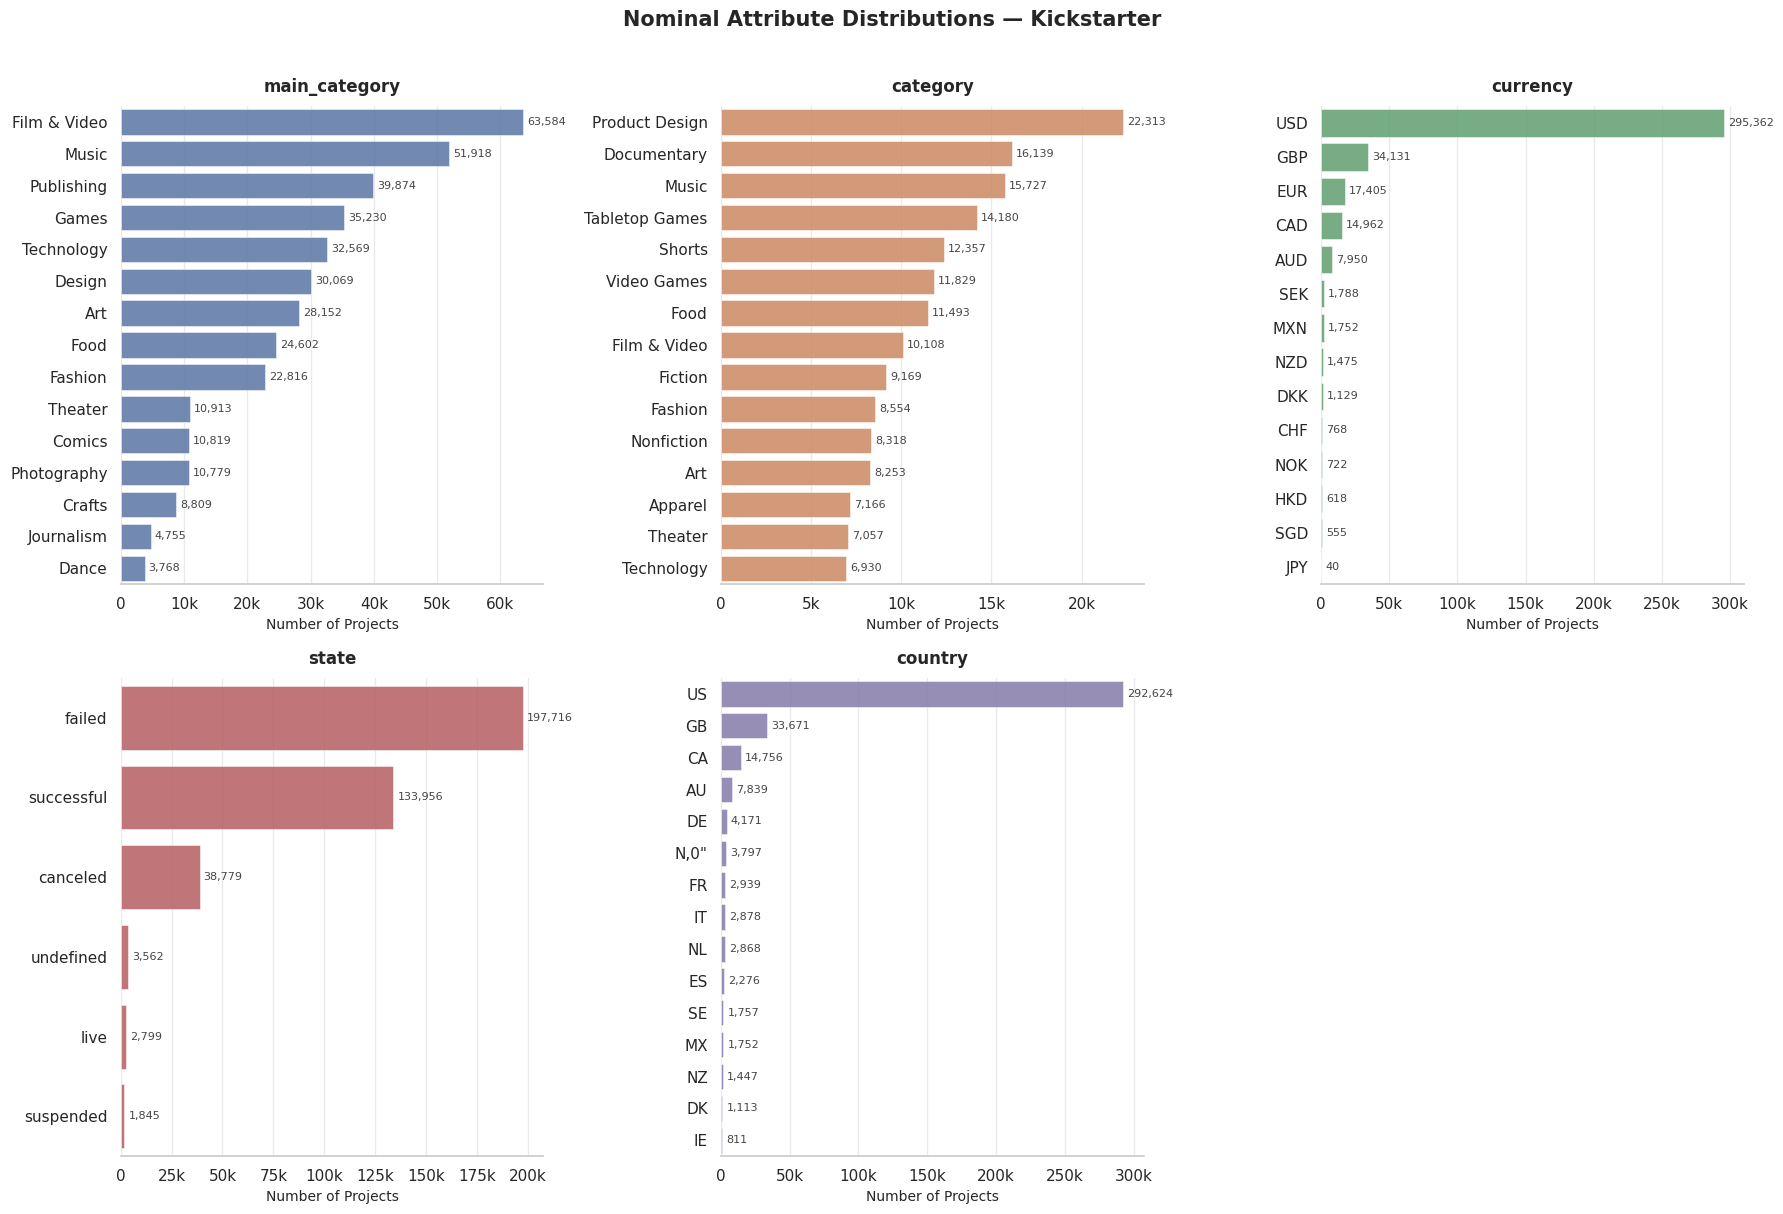

In [47]:
nominal_cols = ['main_category', 'category', 'currency', 'state', 'country']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(nominal_cols):
    ax = axes[i]
    counts = df[col].value_counts().head(15)

    sns.barplot(
        x=counts.values,
        y=counts.index,
        ax=ax,
        color=colors[i],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.4
    )

    for bar, val in zip(ax.patches, counts.values):
        ax.text(
            bar.get_width() + counts.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}',
            va='center', fontsize=8, color='#444'
        )

    ax.set_title(col, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Number of Projects', fontsize=10)
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}'
    ))
    sns.despine(ax=ax, left=True)
    ax.grid(axis='x', alpha=0.4)
    ax.tick_params(left=False)

axes[-1].set_visible(False)

fig.suptitle('Nominal Attribute Distributions - Kickstarter',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Numerical Feature Distributions (with outliers)

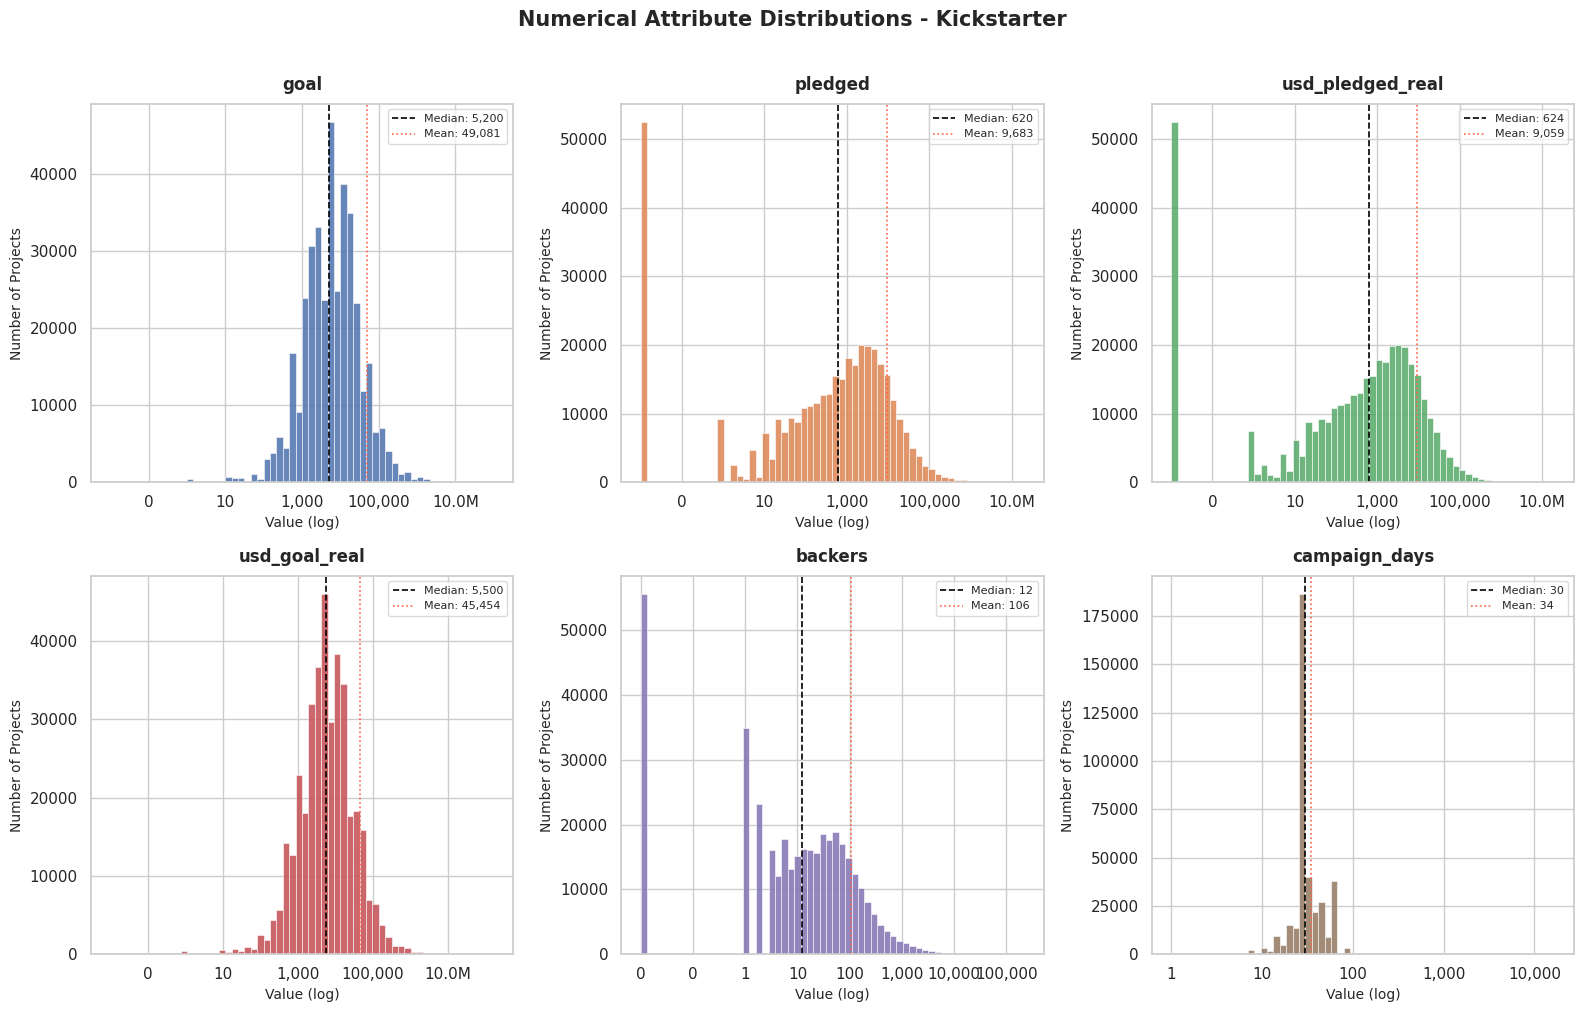

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

numeric_cols = ['goal', 'pledged', 'usd_pledged_real', 'usd_goal_real', 'backers', 'campaign_days']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna().clip(lower=0.01)

    sns.histplot(
        data,
        bins=60,
        log_scale=True,
        ax=ax,
        color=colors[i],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.4
    )

    median = data.median()
    mean   = data.mean()
    ax.axvline(median, color='black',  linestyle='--', linewidth=1.2, label=f'Median: {median:,.0f}')
    ax.axvline(mean,   color='tomato', linestyle=':',  linewidth=1.2, label=f'Mean: {mean:,.0f}')

    ax.set_title(col, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Value (log)', fontsize=10)
    ax.set_ylabel('Number of Projects', fontsize=10)
    ax.legend(fontsize=8, framealpha=0.7)

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}' if x < 1_000_000 else f'{x/1_000_000:.1f}M'
    ))

fig.suptitle('Numerical Attribute Distributions - Kickstarter',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

### State analysis

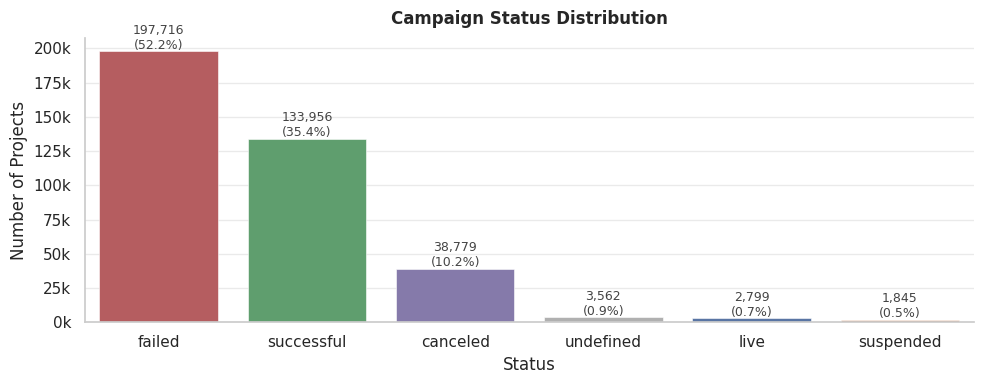

In [49]:
state_palette = {
    'successful': '#55A868',
    'failed':     '#C44E52',
    'canceled':   '#8172B2',
    'live':       '#4C72B0',
    'suspended':  '#DD8452',
    'undefined':  '#B0B0B0'
}

counts = df['state'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette=[state_palette[s] for s in counts.index],
    ax=ax,
    legend=False,
    edgecolor='white',
    linewidth=0.4
)

for bar, val in zip(ax.patches, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f'{val:,.0f}\n({val/len(df):.1%})',
        ha='center', fontsize=9, color='#444'
    )

ax.set_title('Campaign Status Distribution', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Status')
ax.set_ylabel('Number of Projects')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
sns.despine(ax=ax)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()

### Correlation analysis

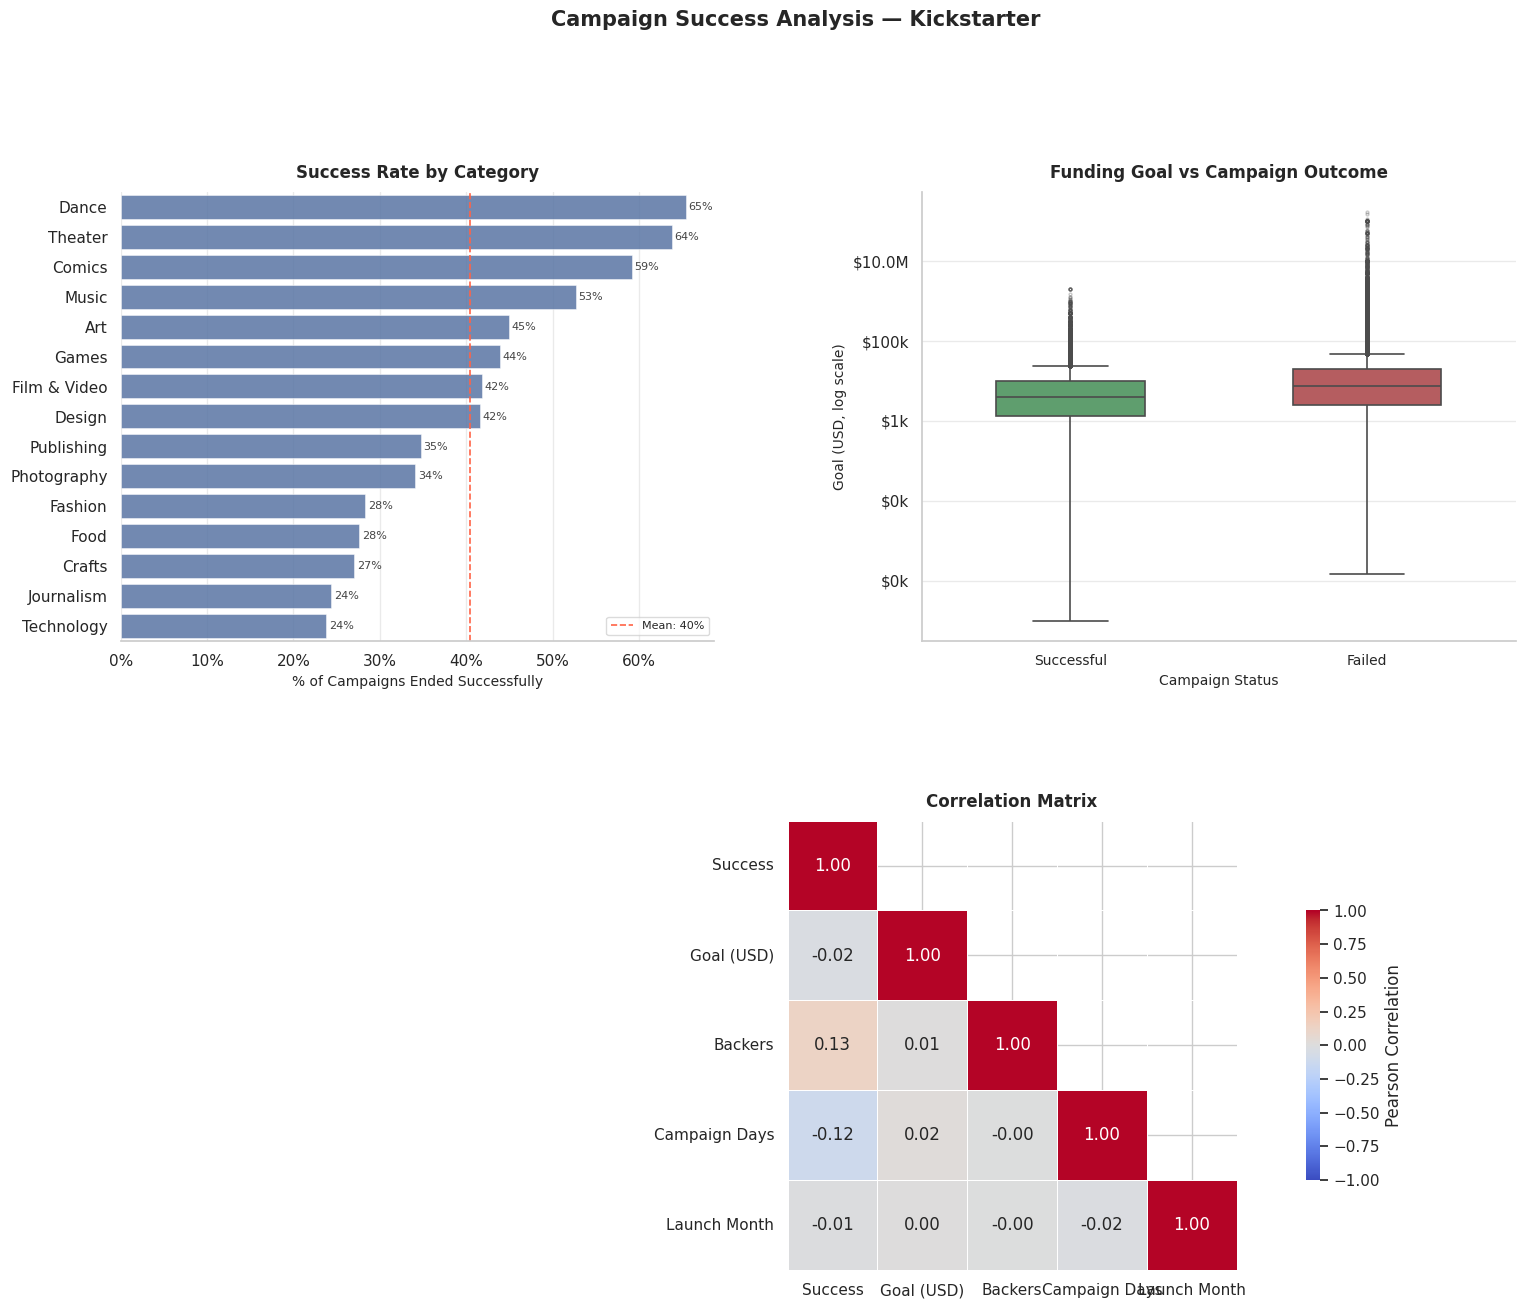

In [50]:
df_main = df[df['state'].isin(['successful', 'failed'])].copy()
df_main['success'] = (df_main['state'] == 'successful').astype(int)

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# ── 1. Success Rate by Category ────────────────────────────────────────
success_by_cat = (
    df_main.groupby('main_category')['success']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

sns.barplot(
    data=success_by_cat,
    x='mean', y='main_category',
    color='#4C72B0',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.4,
    ax=ax1,
)

for bar, (_, row) in zip(ax1.patches, success_by_cat.iterrows()):
    ax1.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{row['mean']:.0%}",
        va='center', fontsize=8, color='#444'
    )

ax1.set_title('Success Rate by Category', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('% of Campaigns Ended Successfully', fontsize=10)
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax1.axvline(df_main['success'].mean(), color='tomato', linestyle='--',
            linewidth=1.2, label=f"Mean: {df_main['success'].mean():.0%}")
ax1.legend(fontsize=8, framealpha=0.7)
sns.despine(ax=ax1, left=True)
ax1.grid(axis='x', alpha=0.4)
ax1.tick_params(left=False)

# ── 2. Funding Goal vs Campaign Outcome ────────────────────────────────────────
state_order = ['successful', 'failed']

sns.boxplot(
    data=df_main,
    x='state', y='usd_goal_real',
    order=state_order,
    hue='state',
    hue_order=state_order,
    palette={'successful': '#55A868', 'failed': '#C44E52'},
    legend=False,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'),
    ax=ax2,
)

ax2.set_yscale('log')
ax2.set_title('Funding Goal vs Campaign Outcome', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Campaign Status', fontsize=10)
ax2.set_ylabel('Goal (USD, log scale)', fontsize=10)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'${x/1_000:.0f}k' if x < 1_000_000 else f'${x/1_000_000:.1f}M'
))
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Successful', 'Failed'], fontsize=10)
sns.despine(ax=ax2)
ax2.grid(axis='y', alpha=0.4)

# ── 3. Correlation Heatmap ────────────────────────────────────────────────────
corr_cols   = ['success', 'usd_goal_real', 'backers', 'campaign_days', 'launch_month']
corr_labels = ['Success', 'Goal (USD)', 'Backers', 'Campaign Days', 'Launch Month']

corr = df_main[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    ax=ax3,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': 'Pearson Correlation'},
    xticklabels=corr_labels,
    yticklabels=corr_labels,
)

ax3.set_title('Correlation Matrix', fontsize=12, fontweight='bold', pad=10)
ax3.tick_params(axis='x', rotation=0)
ax3.tick_params(axis='y', rotation=0)

fig.suptitle('Campaign Success Analysis — Kickstarter',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### Outliers

In [57]:
from scipy import stats

cols = ['usd_goal_real', 'usd_pledged_real', 'backers']
results = {}

for col in cols:
    data = df_main[col].dropna()
    z = np.abs(stats.zscore(data))
    n_out = (z > 3).sum()
    results[col] = {
        'count':   int(n_out),
        'pct':     n_out / len(df_main) * 100,
        'min_out': data[z > 3].min(),
        'max_out': data[z > 3].max(),
    }

for col, r in results.items():
    print(f"{col:20s}  {r['count']:>6,} outliers  {r['pct']:.2f}%  "
          f"  range: {r['min_out']:,.0f} – {r['max_out']:,.0f}")

usd_goal_real            304 outliers  0.09%    range: 3,433,123 – 166,361,391
usd_pledged_real       1,337 outliers  0.40%    range: 300,316 – 20,338,986
backers                1,541 outliers  0.46%    range: 3,014 – 219,382


### Time-based trends

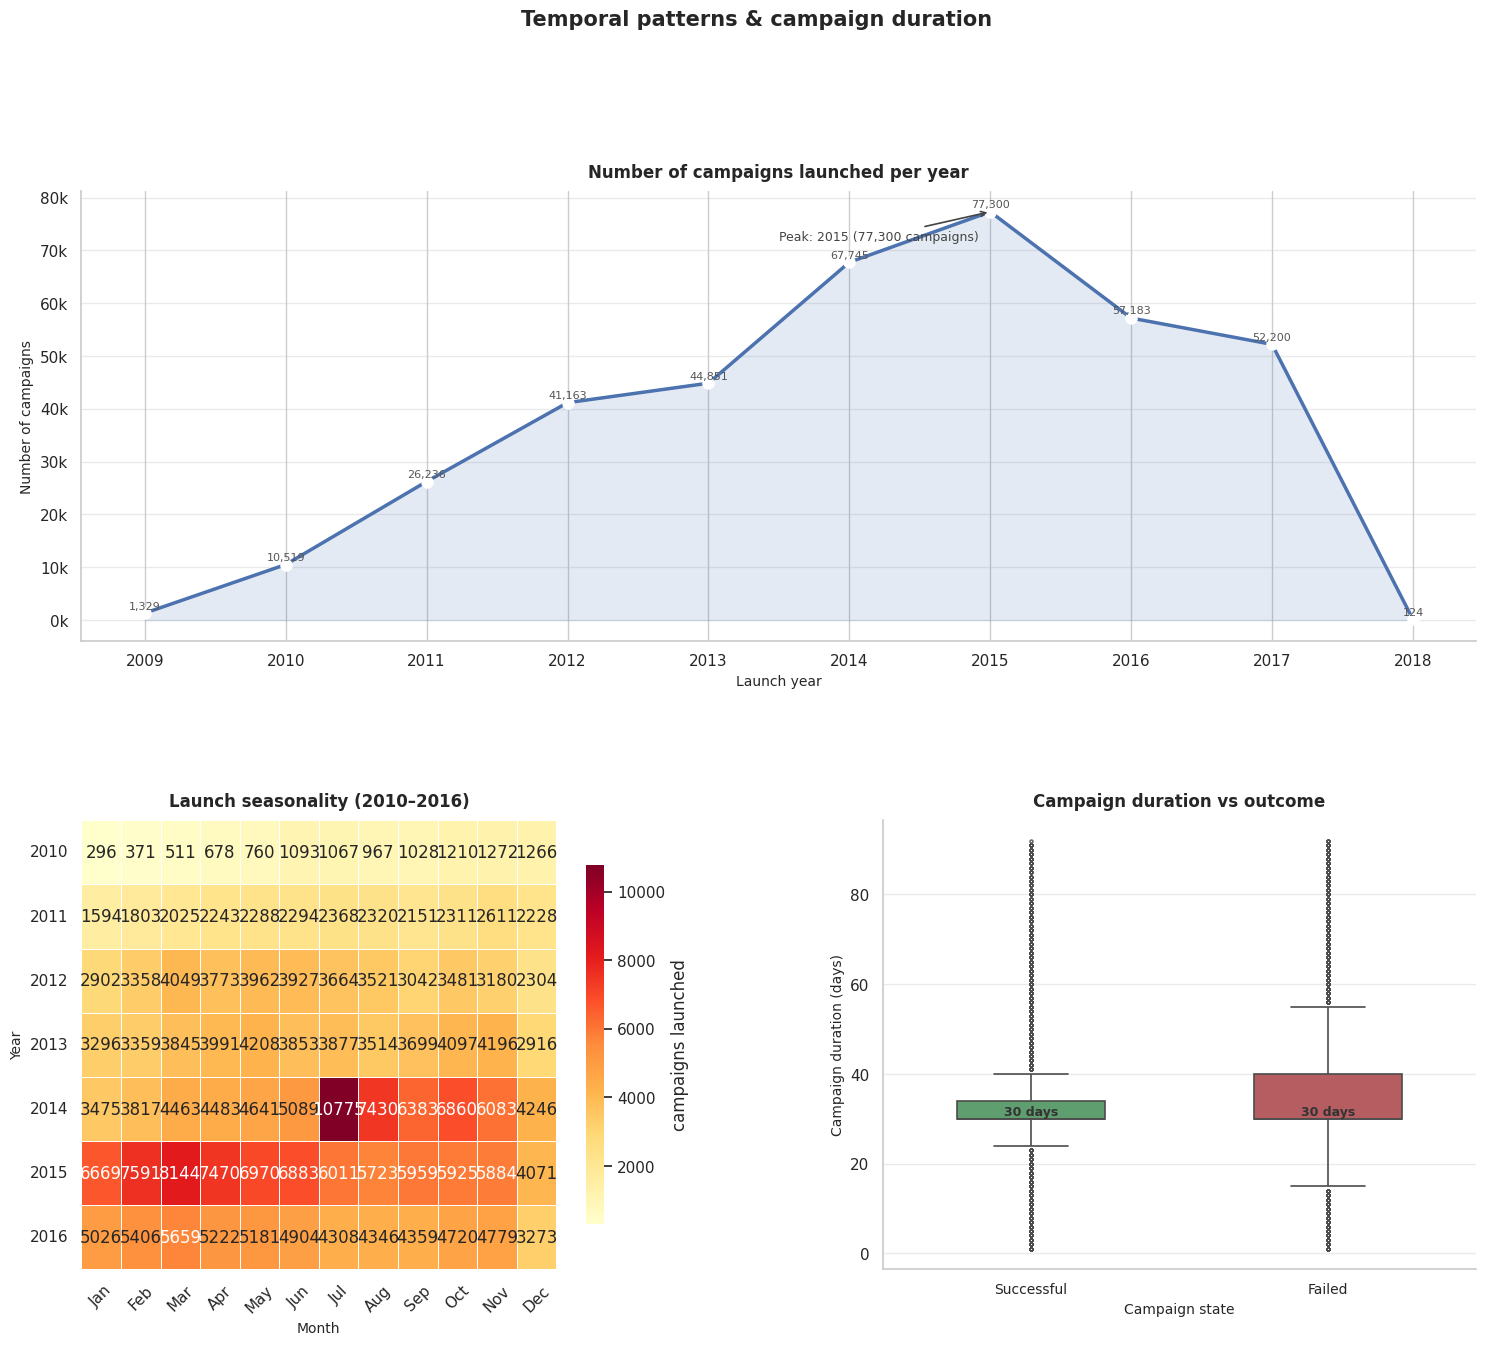

In [61]:
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# ── 1. yearly trend ──────────────────────────────────────────────────────────
trend_year = df.groupby('launch_year').size().reset_index(name='count')

ax1.fill_between(trend_year['launch_year'], trend_year['count'],
                 alpha=0.15, color='#4C72B0')
sns.lineplot(data=trend_year, x='launch_year', y='count',
             ax=ax1, color='#4C72B0', linewidth=2.5, marker='o',
             markersize=7, markerfacecolor='white', markeredgewidth=2)

peak_year = trend_year.loc[trend_year['count'].idxmax()]
ax1.annotate(
    f"Peak: {int(peak_year['launch_year'])} ({peak_year['count']:,} campaigns)",
    xy=(peak_year['launch_year'], peak_year['count']),
    xytext=(peak_year['launch_year'] - 1.5, peak_year['count'] * 0.93),
    arrowprops=dict(arrowstyle='->', color='#444', lw=1.2),
    fontsize=9, color='#444'
)

for _, row in trend_year.iterrows():
    ax1.text(row['launch_year'], row['count'] + 800,
             f"{int(row['count']):,}", ha='center', fontsize=8, color='#555')

ax1.set_title('Number of campaigns launched per year', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Launch year', fontsize=10)
ax1.set_ylabel('Number of campaigns', fontsize=10)
ax1.set_xticks(trend_year['launch_year'])
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
sns.despine(ax=ax1)
ax1.grid(axis='y', alpha=0.4)

# ── 2. monthly seasonality (heatmap year x month) ────────────────────────────
trend_month = (
    df[df['launch_year'].between(2010, 2016)]
    .groupby(['launch_year', 'launch_month'])
    .size()
    .unstack(fill_value=0)
)
trend_month.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(trend_month, ax=ax2, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'campaigns launched', 'shrink': 0.8})
ax2.set_title('Launch seasonality (2010–2016)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Month', fontsize=10)
ax2.set_ylabel('Year', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

# ── 3. campaign_days vs success ──────────────────────────────────────────────
state_order = ['successful', 'failed']

sns.boxplot(
    data=df_main,
    x='state', y='campaign_days',
    order=state_order,
    hue='state', hue_order=state_order,
    palette={'successful': '#55A868', 'failed': '#C44E52'},
    legend=False,
    width=0.5, linewidth=1.2,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'),
    ax=ax3,
)

for i, state in enumerate(state_order):
    median = df_main[df_main['state'] == state]['campaign_days'].median()
    ax3.text(i, median + 0.8, f'{median:.0f} days',
             ha='center', fontsize=9, fontweight='bold', color='#333')

ax3.set_title('Campaign duration vs outcome', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Campaign state', fontsize=10)
ax3.set_ylabel('Campaign duration (days)', fontsize=10)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Successful', 'Failed'], fontsize=10)
sns.despine(ax=ax3)
ax3.grid(axis='y', alpha=0.4)

fig.suptitle('Temporal patterns & campaign duration', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()